# Decisions: the lounge scorecard and the growth rule, calibrated

`src.model.scorecard.decide(features)` turns each lounge's features (`features.ipynb`) into
PROTECT / HOLD / SHRINK from four signals on **fixed scales**; `src.model.growth.classify(area)`
labels each growth area GROW / WATCH / SKIP. This notebook shows where the anchors and thresholds
come from, what they decide at medium levels, how the calls move across the 27 level combinations,
and the two open questions from the plan review. **Every anchor here is a proposal the user
reviews before it is frozen.** No model logic of its own except the two alternatives in sections
5 and 6, computed inline for comparison.

Data: `data/seed/v3/` via `src.data_v3.load_v3()`; assumptions in `data/scenarios/baseline.yaml`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import itertools
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import load_baseline_assumptions
from src.data_v3 import LEVELS, load_v3
from src.features import lounges as L
from src.features.lounges import build
from src.market import premium_substitutes, women_15plus
from src.model import growth, scorecard
from src.model.scorecard import PROTECT_AT, SHRINK_AT, SIGNALS, score
from src.models import Levels

pd.set_option("display.width", 160)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.2, "grid.color": "#888", "axes.edgecolor": "#999", "font.size": 9})
BLUE, ORANGE, AQUA, YELLOW, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#9e9e9e", "#d64545"
ACTION_COLOR = {"PROTECT": AQUA, "HOLD": GREY, "SHRINK": ORANGE, "NOT SCORED": "#ddd",
                "GROW": AQUA, "WATCH": YELLOW, "SKIP": GREY}

A = load_baseline_assumptions(ROOT / "data/scenarios/baseline.yaml")
v3 = load_v3()
df = lambda rows: pd.DataFrame([r.model_dump() for r in rows])
feats, areas = build(v3, A)
F = df(feats).set_index("branch_id")
D = df(scorecard.decide(feats)).set_index("branch_id")
AR = df(areas).set_index("area_id")
AD = df(growth.classify_all(areas)).set_index("area_id")
scored = F[~F.not_scored]
print(f"{len(F)} lounges ({F.not_scored.sum()} not scored), {len(AR)} growth areas at medium levels")

24 lounges (1 not scored), 580 growth areas at medium levels


## 1. The anchors

Four signals, each scored 0-1 on a fixed scale (clipped), averaged with equal weights.
PROTECT at a composite ≥ 0.65, SHRINK ≤ 0.35, HOLD between. A thin premium market (fewer than 10
premium salons) scores capture 0.5 and makes confidence "low"; a missing rating gap scores 0.5.
The airport lounge is NOT SCORED (it serves travellers) and stays out of every count.

In [2]:
pd.DataFrame([{"signal": s.name, "field": s.field, "0 at": s.worst, "1 at": s.best, "why": s.why} for s in SIGNALS]).style.hide(axis="index")

signal,field,0 at,1 at,why
demand,catchment_women,0.000000,200000.000000,"Lounges range 23k-272k women, median 105k; 200k is where the four big Dubai lounges sit, and one lounge can't absorb more, so extra women stop counting."
cannibalisation,shared_share,1.000000,0.000000,Already a 0-100% share: 0% means no sibling reaches this lounge's women. Abu Dhabi city lounges sit at 85-100%.
capture,capture,0.000000,0.150000,"Median 5.8%; 15% is about the best reliable lounge (al-taif-mall, 14%). Thin premium markets (under 10 premium salons) score 0.5: a share of a tiny pool is noise."
rating,rating_gap,-0.300000,0.300000,"Gaps run -0.2 to +0.3, median -0.1: most lounges rate slightly below their premium substitutes; ±0.3 stars covers the whole range."


## 2. Signal distributions with the anchors

Each dot is a scored lounge at medium levels (orange: thin premium market). The shaded band runs
from the 0-anchor to the 1-anchor; values outside it clip.

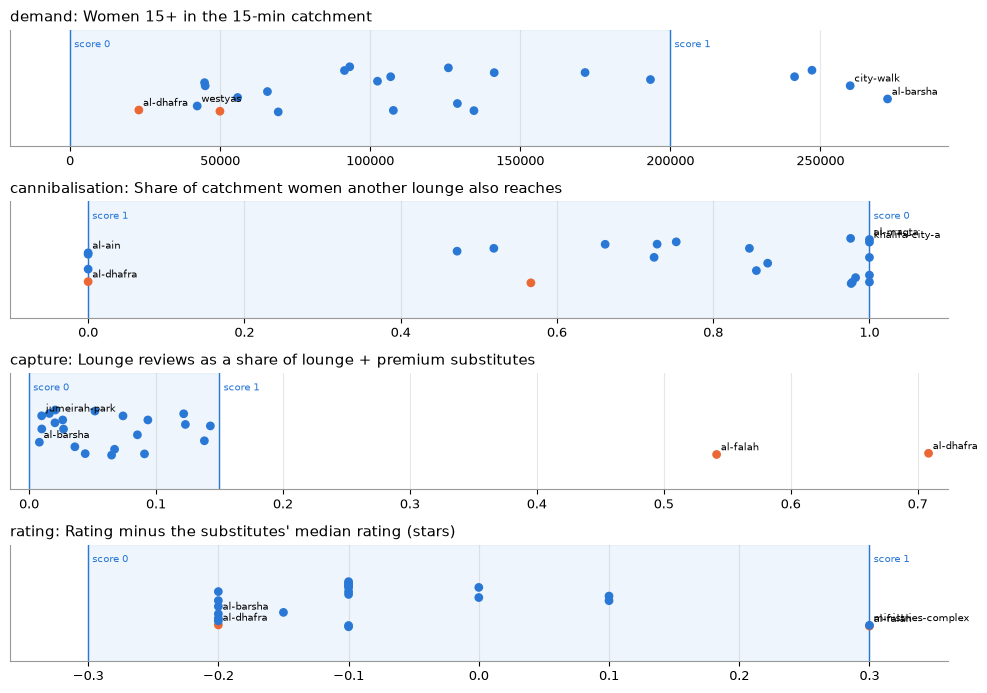

,catchment_women,shared_share,capture,rating_gap
count,23.000,23.000,23.000,23.000
mean,122370.770,0.692,0.110,-0.072
std,75627.066,0.363,0.170,0.147
min,22927.304,0.000,0.008,-0.200
25%,60804.427,0.543,0.024,-0.200
50%,106825.818,0.846,0.065,-0.100
75%,156462.171,0.980,0.108,-0.050
max,272370.641,1.000,0.709,0.300


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 7))
for ax, s in zip(axes, SIGNALS):
    x = scored[s.field].astype(float)
    lo, hi = sorted((s.worst, s.best))
    ax.axvspan(lo, hi, color=BLUE, alpha=0.07)
    for v, t in ((s.worst, "0"), (s.best, "1")):
        ax.axvline(v, color=BLUE, lw=1); ax.annotate(f"score {t}", (v, 0.85), xycoords=("data", "axes fraction"), fontsize=7, color=BLUE, xytext=(3, 0), textcoords="offset points")
    jit = np.random.default_rng(0).uniform(-0.25, 0.25, len(x))
    ax.scatter(x, jit, c=np.where(scored.thin_premium_market, ORANGE, BLUE), s=28, zorder=3)
    for b in x.nlargest(2).index.union(x.nsmallest(2).index):
        ax.annotate(b, (x[b], jit[list(x.index).index(b)]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_ylim(-0.6, 0.6); ax.set_yticks([]); ax.set_title(f"{s.name}: {s.label}", loc="left")
    pad = (hi - lo) * 0.1
    ax.set_xlim(min(lo, x.min()) - pad, max(hi, x.max()) + pad)
plt.tight_layout(); plt.show()
scored[[s.field for s in SIGNALS]].describe().round(3)

## 3. Composite and action per lounge, medium levels

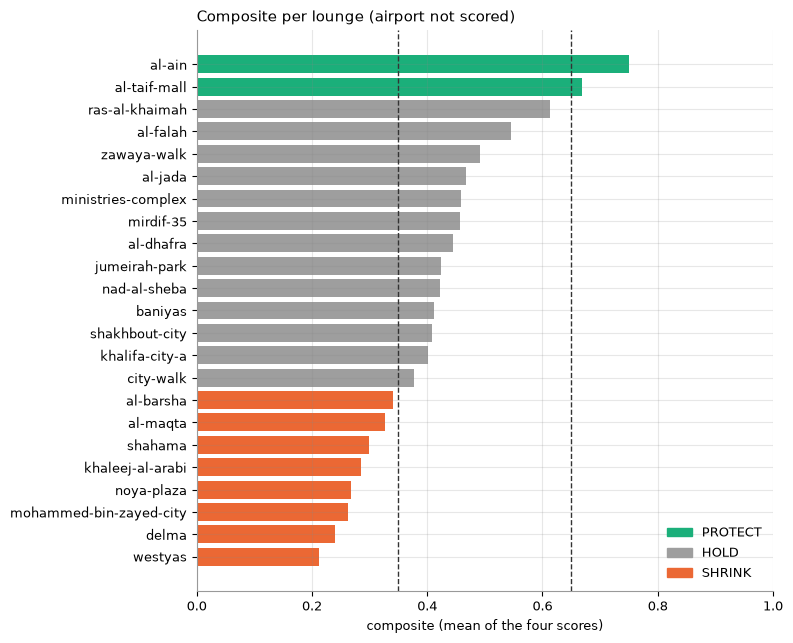

{'PROTECT': 2, 'HOLD': 13, 'SHRINK': 8} + 1 NOT SCORED


,emirate,action,confidence,composite,demand,cannibalisation,capture,rating,thin_premium_market,key_drivers
branch_id,,,,,,,,,,
zayed-international-airport,Abu Dhabi,NOT SCORED,low,0.000,NaN,NaN,NaN,NaN,False,[]
westyas,Abu Dhabi,SHRINK,high,0.211,0.212,0.018,0.449,0.167,False,"[cannibalisation, rating]"
delma,Abu Dhabi,SHRINK,high,0.240,0.466,0.024,0.138,0.333,False,"[cannibalisation, capture]"
mohammed-bin-zayed-city,Abu Dhabi,SHRINK,medium,0.263,0.645,0.000,0.241,0.167,False,"[cannibalisation, rating]"
noya-plaza,Abu Dhabi,SHRINK,medium,0.268,0.225,0.000,0.181,0.667,False,"[cannibalisation, capture]"
khaleej-al-arabi,Abu Dhabi,SHRINK,medium,0.284,0.347,0.023,0.434,0.333,False,"[cannibalisation, rating]"
shahama,Abu Dhabi,SHRINK,medium,0.299,0.329,0.130,0.569,0.167,False,"[cannibalisation, rating]"
al-maqta,Abu Dhabi,SHRINK,low,0.327,0.630,0.000,0.346,0.333,False,"[cannibalisation, rating]"
al-barsha,Dubai,SHRINK,low,0.341,1.000,0.145,0.054,0.167,False,"[demand, capture]"


In [4]:
t = D.join(F[["emirate", "thin_premium_market"]]).drop(columns=["rationale", "caveats"])
t = pd.concat([t, t.pop("scores").apply(pd.Series)], axis=1).sort_values("composite")
fig, ax = plt.subplots(figsize=(8, 6.5))
tb = t[t.action != "NOT SCORED"]
ax.barh(tb.index, tb.composite, color=[ACTION_COLOR[a] for a in tb.action])
for v in (SHRINK_AT, PROTECT_AT):
    ax.axvline(v, color="#333", lw=1, ls="--")
ax.set_xlabel("composite (mean of the four scores)"); ax.set_xlim(0, 1)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ACTION_COLOR[a]) for a in ("PROTECT", "HOLD", "SHRINK")],
          labels=["PROTECT", "HOLD", "SHRINK"], frameon=False, loc="lower right")
ax.set_title("Composite per lounge (airport not scored)", loc="left")
plt.tight_layout(); plt.show()
print(scorecard.counts(scorecard.decide(feats)), "+", (D.action == "NOT SCORED").sum(), "NOT SCORED")
t[["emirate", "action", "confidence", "composite", "demand", "cannibalisation", "capture", "rating", "thin_premium_market", "key_drivers"]].round(3)

**Reading it.** al-ain and al-taif-mall are PROTECT: catchments no other lounge reaches and the
best reliable capture (12-14%). The eight SHRINKs are al-barsha plus seven Abu Dhabi city lounges with
87-100% of their women shared with siblings and middling-to-low capture. al-barsha is the one to question: Dubai's biggest
catchment (demand scores 1), but it captures under 1% of a crowded premium market and shares 86%
of its women. al-falah and al-dhafra are thin markets: capture is neutral, confidence low.

## 4. How the actions move across all 27 level combinations

Travel time (10 / 15 / 20 min) x competitor coverage (50 / 60 / 70%) x worker-housing female share
(1 / 5.5 / 15%). **Flips** = combinations (of 27) whose action differs from the medium-levels
action. Not wired into confidence yet: that waits for the user's review.

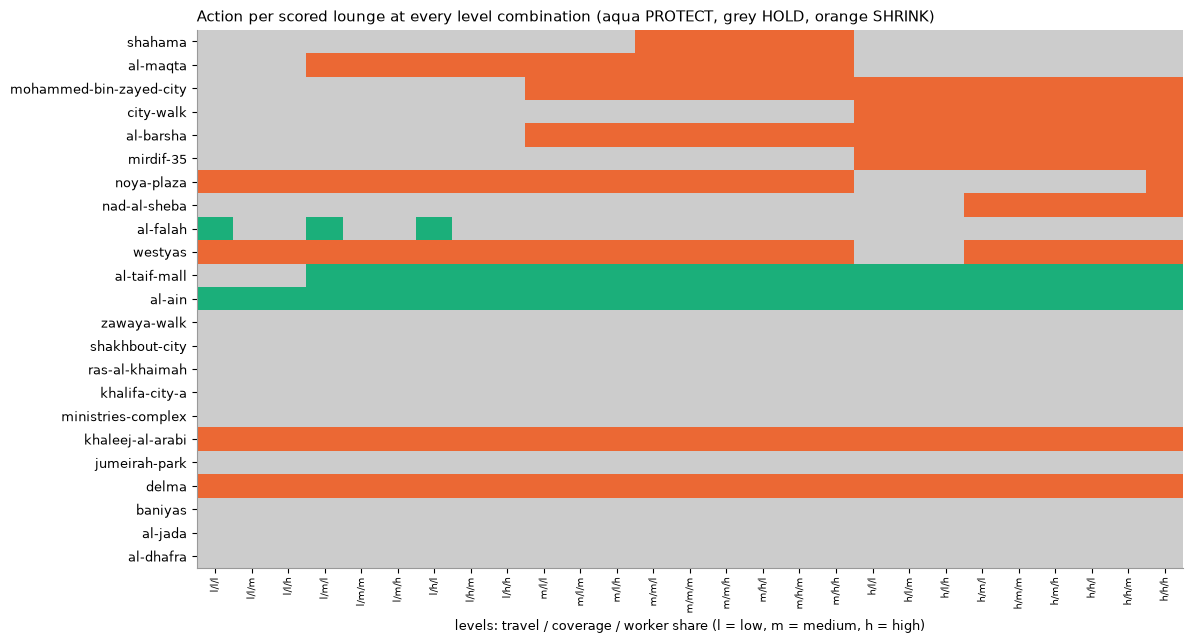

lounges that never flip: 12 of 23


,medium,confidence,flips,actions over 27
shahama,SHRINK,medium,21,"{'HOLD': 21, 'SHRINK': 6}"
al-maqta,SHRINK,low,12,"{'HOLD': 12, 'SHRINK': 15}"
mohammed-bin-zayed-city,SHRINK,medium,9,"{'HOLD': 9, 'SHRINK': 18}"
city-walk,HOLD,low,9,"{'HOLD': 18, 'SHRINK': 9}"
al-barsha,SHRINK,low,9,"{'HOLD': 9, 'SHRINK': 18}"
mirdif-35,HOLD,high,9,"{'HOLD': 18, 'SHRINK': 9}"
noya-plaza,SHRINK,medium,8,"{'SHRINK': 19, 'HOLD': 8}"
nad-al-sheba,HOLD,medium,6,"{'HOLD': 21, 'SHRINK': 6}"
al-falah,HOLD,low,3,"{'PROTECT': 3, 'HOLD': 24}"
westyas,SHRINK,high,3,"{'SHRINK': 24, 'HOLD': 3}"


In [5]:
combos = list(itertools.product(LEVELS, repeat=3))
runs = {lv: build(v3, A, Levels(*lv)) for lv in combos}
ACT = pd.DataFrame({lv: {d.branch_id: d.action for d in scorecard.decide(runs[lv][0])} for lv in combos})
flips = ACT.ne(D.action, axis=0).sum(axis=1).rename("flips")
mix = ACT.apply(lambda r: dict(Counter(r)), axis=1).rename("actions over 27")
FL = pd.concat([D.action.rename("medium"), D.confidence, flips, mix], axis=1).sort_values("flips", ascending=False)
order = {"PROTECT": 2, "HOLD": 1, "SHRINK": 0, "NOT SCORED": np.nan}
fig, ax = plt.subplots(figsize=(12, 6.5))
M = ACT.loc[FL.index[FL.medium != "NOT SCORED"]].replace(order).astype(float)
ax.imshow(M, aspect="auto", cmap=plt.matplotlib.colors.ListedColormap([ORANGE, "#ccc", AQUA]), vmin=0, vmax=2)
ax.set_yticks(range(len(M)), M.index); ax.set_xticks(range(27), ["/".join(x[0] for x in lv) for lv in combos], rotation=90, fontsize=7)
ax.set_xlabel("levels: travel / coverage / worker share (l = low, m = medium, h = high)"); ax.grid(False)
ax.set_title("Action per scored lounge at every level combination (aqua PROTECT, grey HOLD, orange SHRINK)", loc="left")
plt.tight_layout(); plt.show()
print("lounges that never flip:", (flips[D.action != "NOT SCORED"] == 0).sum(), "of", (D.action != "NOT SCORED").sum())
FL[FL.medium != "NOT SCORED"]

In [6]:
print("One level moved at a time, the other two at medium: lounges whose action changes")
for i, dim in enumerate(["travel", "coverage", "worker_share"]):
    for lv in ("low", "high"):
        c = tuple(lv if j == i else "medium" for j in range(3))
        moved = ACT[c][ACT[c] != D.action]
        print(f"  {dim:>12} {lv:>4}: " + (", ".join(f"{b} -> {a}" for b, a in moved.items()) or "none"))

One level moved at a time, the other two at medium: lounges whose action changes
        travel  low: al-barsha -> HOLD, mohammed-bin-zayed-city -> HOLD, shahama -> HOLD
        travel high: al-maqta -> HOLD, city-walk -> SHRINK, mirdif-35 -> SHRINK, nad-al-sheba -> SHRINK, noya-plaza -> HOLD, shahama -> HOLD
      coverage  low: shahama -> HOLD
      coverage high: none
  worker_share  low: none
  worker_share high: none


**Reading it.** Travel time drives the movement: at 10 min catchments shrink and capture rises (three
SHRINKs become HOLD); at 20 min Dubai's city-walk, mirdif-35 and nad-al-sheba drop to SHRINK and
three Abu Dhabi lounges rise to HOLD. Coverage moves only shahama; the worker-housing share alone moves
nobody. 12 of 23 lounges never flip. The margin rule doesn't catch all the flippers: **shahama** flips in
21 of 27 combinations at "medium" confidence and **mirdif-35** in 9 at "high". That is the case for
wiring flips into confidence, which the user decides.

## 5. Open question (a): do Demand and Capture cancel?

Capture's denominator is the reviews of competing premium salons, and busier catchments have more of
them. So equal weights reward a big catchment on Demand and penalise it on Capture. The alternative:
one signal, **estimated customers** (capture x catchment women), in place of the two, anchored the same
way (0 at 0, 1 at about the best reliable lounge), giving three signals.

Spearman(catchment women, capture) = -0.74 over 23 scored lounges
best non-thin est_customers: {'al-ain': 12617.0, 'shakhbout-city': 12239.0, 'khalifa-city-a': 11140.0} ; median 4766
thin markets' est_customers (scored neutral, as capture is): {'al-dhafra': 16247.0, 'al-falah': 27054.0}


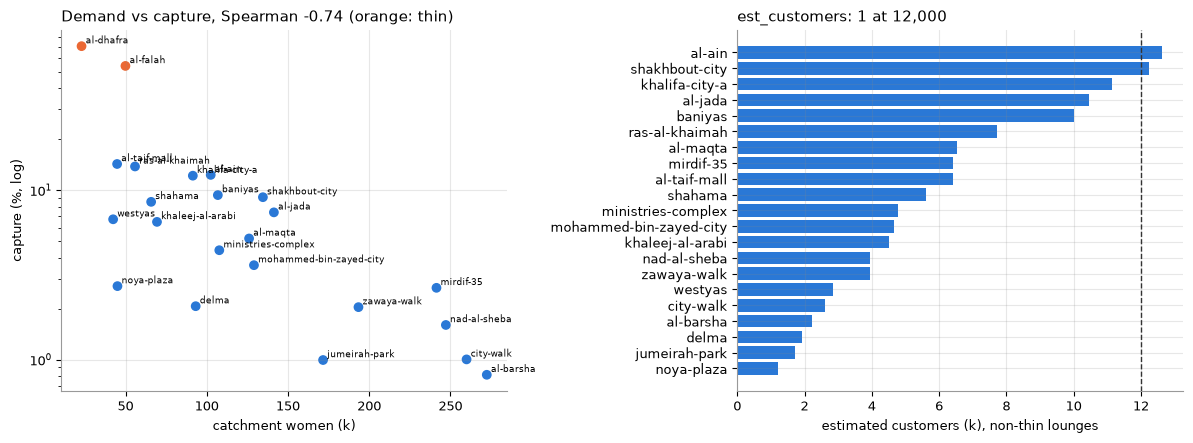

In [7]:
rho = scored.catchment_women.corr(scored.capture, method="spearman")
reliable = scored[~scored.thin_premium_market].est_customers.sort_values(ascending=False)
EST_BEST = 12_000   # proposal: ≈ the best reliable lounges (printed below)
print(f"Spearman(catchment women, capture) = {rho:+.2f} over {len(scored)} scored lounges")
print("best non-thin est_customers:", reliable.head(3).round(0).to_dict(), "; median", round(reliable.median()))
print("thin markets' est_customers (scored neutral, as capture is):", scored[scored.thin_premium_market].est_customers.round(0).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.scatter(scored.catchment_women / 1000, scored.capture * 100, c=np.where(scored.thin_premium_market, ORANGE, BLUE))
for b, r in scored.iterrows():
    ax.annotate(b, (r.catchment_women / 1000, r.capture * 100), fontsize=6.5, xytext=(3, 2), textcoords="offset points")
ax.set_yscale("log"); ax.set_xlabel("catchment women (k)"); ax.set_ylabel("capture (%, log)")
ax.set_title(f"Demand vs capture, Spearman {rho:+.2f} (orange: thin)", loc="left")
ax = axes[1]
ax.barh(reliable.index[::-1], reliable[::-1] / 1000, color=BLUE)
ax.axvline(EST_BEST / 1000, color="#333", ls="--", lw=1); ax.set_xlabel("estimated customers (k), non-thin lounges")
ax.set_title(f"est_customers: 1 at {EST_BEST:,}", loc="left")
plt.tight_layout(); plt.show()

In [8]:
SIG = {s.name: s for s in SIGNALS}
S = t.loc[t.action != "NOT SCORED", ["demand", "cannibalisation", "capture", "rating"]].copy()   # airport out
est = np.where(scored.thin_premium_market, 0.5, (scored.est_customers / EST_BEST).clip(0, 1))
S["est_customers"] = pd.Series(est, scored.index)
call = lambda c: np.where(c >= PROTECT_AT, "PROTECT", np.where(c <= SHRINK_AT, "SHRINK", "HOLD"))
ALT = pd.DataFrame({
    "drafted": S[["demand", "cannibalisation", "capture", "rating"]].mean(axis=1),
    "a: est_customers": S[["est_customers", "cannibalisation", "rating"]].mean(axis=1),
    "b: rating half weight": (S.demand + S.cannibalisation + S.capture + 0.5 * S.rating) / 3.5,
    "b: rating out (tie-breaker only)": S[["demand", "cannibalisation", "capture"]].mean(axis=1)}, index=S.index)
CALLS = ALT.apply(call)
lists = pd.DataFrame({c: {a: ", ".join(sorted(CALLS.index[CALLS[c] == a])) or "-" for a in ("PROTECT", "SHRINK")}
                      | {"counts P/H/S": "/".join(str((CALLS[c] == a).sum()) for a in ("PROTECT", "HOLD", "SHRINK"))} for c in CALLS})
display(lists.style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"}))
changed = CALLS[CALLS.nunique(axis=1) > 1]
print("Lounges whose call depends on the variant:")
pd.concat([ALT.loc[changed.index].round(3).add_suffix(" composite"), changed], axis=1)

,drafted,a: est_customers,b: rating half weight,b: rating out (tie-breaker only)
PROTECT,"al-ain, al-taif-mall","al-ain, al-taif-mall","al-ain, al-taif-mall, ras-al-khaimah","al-ain, al-taif-mall, ras-al-khaimah"
SHRINK,"al-barsha, al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas","al-barsha, al-maqta, city-walk, delma, jumeirah-park, khaleej-al-arabi, mohammed-bin-zayed-city, nad-al-sheba, noya-plaza, shahama, westyas","al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas","al-maqta, delma, khaleej-al-arabi, ministries-complex, mohammed-bin-zayed-city, noya-plaza, shahama, westyas"
counts P/H/S,2/13/8,2/10/11,3/13/7,3/12/8


Lounges whose call depends on the variant:


,drafted composite,a: est_customers composite,b: rating half weight composite,b: rating out (tie-breaker only) composite,drafted,a: est_customers,b: rating half weight,b: rating out (tie-breaker only)
branch_id,,,,,,,,
al-barsha,0.341,0.165,0.366,0.400,SHRINK,SHRINK,HOLD,HOLD
city-walk,0.377,0.220,0.407,0.448,HOLD,SHRINK,HOLD,HOLD
nad-al-sheba,0.422,0.304,0.434,0.451,HOLD,SHRINK,HOLD,HOLD
jumeirah-park,0.424,0.305,0.413,0.399,HOLD,SHRINK,HOLD,HOLD
ministries-complex,0.458,0.466,0.381,0.278,HOLD,HOLD,HOLD,SHRINK
ras-al-khaimah,0.613,0.631,0.664,0.733,HOLD,HOLD,PROTECT,PROTECT


**Reading it.** The correlation is strongly negative, so the drafted scorecard does pay for a busy
area twice with opposite signs. Under (a), each lounge's market counts once, as customers, and the
Dubai lounges lose the crutch of a full demand score: city-walk, jumeirah-park and nad-al-sheba join
al-barsha in SHRINK (11 SHRINKs instead of 8). PROTECT is unchanged. In the 12,000 anchor, al-ain,
shakhbout-city and khalifa-city-a (11-13k) are the best non-thin lounges. Decision for the user: keep
four signals as drafted, or switch to (a). (a) is the more honest measure but makes four of the five
Dubai lounges SHRINK, on review counts alone.

## 6. Open question (b): the rating gap is coarse

Google ratings come in steps of 0.1, so the gap takes only a handful of values. And the premium filter
admits unpriced salons only at rating ≥ 4.3, which pulls the substitutes' median up.

distinct rating-gap values: [-0.2, -0.15, -0.1, 0.0, 0.1, 0.3] (6 values)


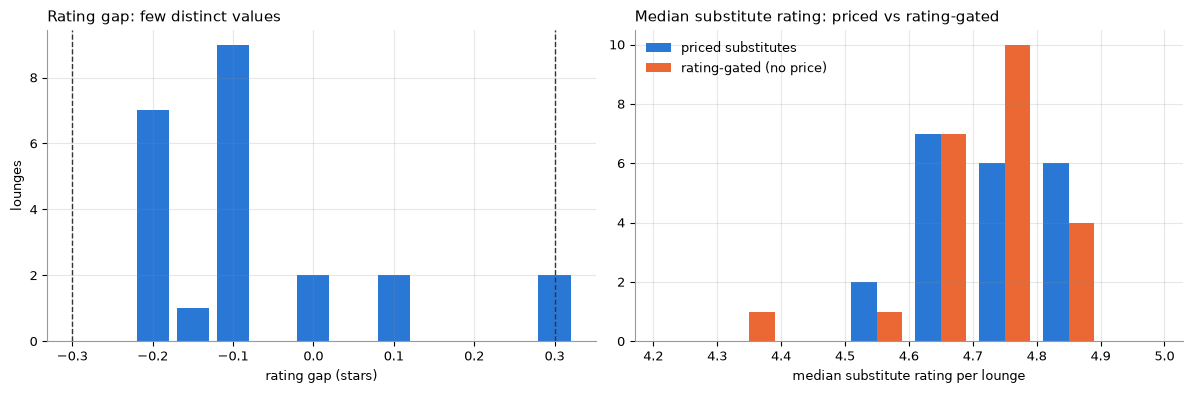

share of substitutes admitted by the rating gate: 45%; median of their per-lounge medians 4.70 vs priced 4.70


,rating,subs,by_price,by_rating_gate,median_priced,median_gated,median_all,gap
branch_id,,,,,,,,
al-barsha,4.6,63,28,35,4.80,4.80,4.80,-0.20
al-dhafra,4.5,3,0,3,NaN,4.70,4.70,-0.20
shahama,4.6,9,5,4,4.80,4.70,4.80,-0.20
mohammed-bin-zayed-city,4.4,18,7,11,4.50,4.70,4.60,-0.20
city-walk,4.6,50,24,26,4.80,4.80,4.80,-0.20
mirdif-35,4.5,23,18,5,4.70,4.60,4.70,-0.20
westyas,4.6,9,5,4,4.80,4.75,4.80,-0.20
ras-al-khaimah,4.5,8,6,2,4.65,4.80,4.65,-0.15
khaleej-al-arabi,4.6,29,15,14,4.70,4.70,4.70,-0.10


In [9]:
gap = scored.rating_gap.round(2)
print("distinct rating-gap values:", [float(x) for x in sorted(gap.dropna().unique())], f"({gap.nunique()} values)")
rows = []
for b in scored.index:
    cands = v3.candidates[(b, "medium")]
    subs = premium_substitutes(cands, len(cands), A.premium_min_rating, A.comparable_price_levels)[:int(F.loc[b, "substitutes_k"])]
    priced = [float(s["rating"]) for s in subs if s.get("price_level") and s.get("rating") is not None]
    gated = [float(s["rating"]) for s in subs if not s.get("price_level") and s.get("rating") is not None]
    rows.append({"branch_id": b, "rating": F.loc[b, "rating"], "subs": len(subs), "by_price": len(priced), "by_rating_gate": len(gated),
                 "median_priced": np.median(priced) if priced else np.nan, "median_gated": np.median(gated) if gated else np.nan,
                 "median_all": F.loc[b, "substitutes_median_rating"], "gap": gap[b]})
RG = pd.DataFrame(rows).set_index("branch_id")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = gap.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, width=0.04, color=BLUE); axes[0].set_xlabel("rating gap (stars)"); axes[0].set_ylabel("lounges")
for v in (SIG["rating"].worst, SIG["rating"].best):
    axes[0].axvline(v, color="#333", ls="--", lw=1)
axes[0].set_title("Rating gap: few distinct values", loc="left")
axes[1].hist([RG.median_priced.dropna(), RG.median_gated.dropna()], bins=np.arange(4.2, 5.05, 0.1), label=["priced substitutes", "rating-gated (no price)"], color=[BLUE, ORANGE])
axes[1].set_xlabel("median substitute rating per lounge"); axes[1].legend(frameon=False)
axes[1].set_title("Median substitute rating: priced vs rating-gated", loc="left")
plt.tight_layout(); plt.show()
print(f"share of substitutes admitted by the rating gate: {RG.by_rating_gate.sum() / RG.subs.sum():.0%}; "
      f"median of their per-lounge medians {RG.median_gated.median():.2f} vs priced {RG.median_priced.median():.2f}")
RG.sort_values("gap").round(2)

**Reading it.** Six distinct values; a 0.1-star step moves the rating score by 1/6 and the composite
by 0.04, enough to cross a threshold for a lounge near one. **The premium-filter suspicion doesn't hold
up:** 45% of substitutes enter through the rating gate, but their per-lounge median rating (4.70) equals
the priced substitutes' (4.70). The negative median gap is real: premium salons near our lounges rate
4.6-4.8 and most lounges rate 4.5-4.6. Section 5's table shows the two remedies: **half weight** keeps
the signal but makes a 0.1-star step worth about 0.024 of composite (al-barsha moves to HOLD,
ras-al-khaimah to PROTECT); **rating out** (shown on the page, used only as a tie-breaker) also moves
ministries-complex, whose only strength is its +0.3 gap, to SHRINK. Our proposal: half weight, since the
gap carries information (ministries-complex's 4.9 is real) but not at full resolution.

## 7. Growth: where to draw the "unsaturated" line

Saturation = premium-salon reviews per 1,000 women 15+, recall-corrected, over the cells our search
covered. To compare like with like, the same measure is computed over each lounge's 15-min catchment
(the cells a lounge already operates in) with the same code as the areas (`lounges._area`).

lounge catchments, non-thin: min 88 (al-jada), median 220; thin: {'al-dhafra': 10.0, 'al-falah': 27.0}
growth areas with >= 5k women and data (54): median 5, 75th pct 54; under the line: 40


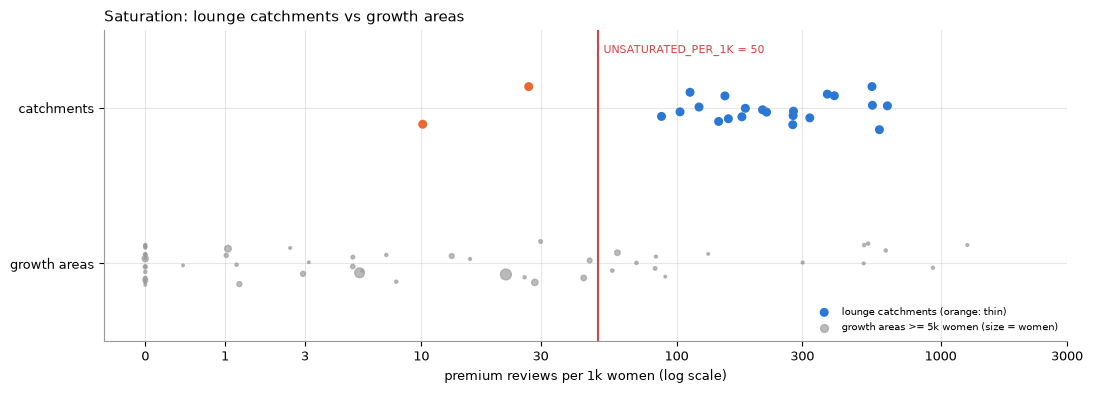

UNSATURATED_PER_1K why: PROPOSAL, pending the user's review. Every lounge catchment with a real premium market (10+ premium salons) has 88+ premium reviews per 1k women (al-jada 88, median 220); the two thin ones are 10 and 27. Growth areas of 5k+ women have a median of 5 and a 75th percentile of 54. 50 is under the least crowded working catchment by a wide margin and splits the growth areas into the empty majority and the ones with an established premium scene.


In [10]:
p = L._prep(v3)
w = women_15plus(v3.cells, v3.emirates, A.worker_housing_female_share["medium"]).to_dict()
lats, lngs = np.array([lo.lat for lo in v3.lounges]), np.array([lo.lng for lo in v3.lounges])
CA = pd.DataFrame([L._area(lo.branch_id, lo.name, lo.emirate, [c for c in p["catch"]["medium"][lo.branch_id] if w[c] > 0],
                           w, p, A, v3.lounges, lats, lngs).model_dump() for lo in v3.lounges]).set_index("area_id")
CA = CA[~F.not_scored.reindex(CA.index)]   # the airport is not a lounge market
CA["thin"] = F.thin_premium_market
line = growth.UNSATURATED_PER_1K
G5 = AR[(AR.women >= growth.SKIP_UNDER_WOMEN) & AR.premium_reviews_per_1k.notna()]
working = CA[~CA.thin].premium_reviews_per_1k
print(f"lounge catchments, non-thin: min {working.min():.0f} ({working.idxmin()}), median {working.median():.0f}; "
      f"thin: {CA[CA.thin].premium_reviews_per_1k.round(0).to_dict()}")
print(f"growth areas with >= 5k women and data ({len(G5)}): median {G5.premium_reviews_per_1k.median():.0f}, "
      f"75th pct {G5.premium_reviews_per_1k.quantile(0.75):.0f}; under the line: {(G5.premium_reviews_per_1k < line).sum()}")
fig, ax = plt.subplots(figsize=(11, 4))
lg = lambda s: np.log10(s + 1)
ax.scatter(lg(CA.premium_reviews_per_1k), np.full(len(CA), 1) + np.random.default_rng(1).uniform(-0.15, 0.15, len(CA)),
           c=np.where(CA.thin, ORANGE, BLUE), s=30, label="lounge catchments (orange: thin)")
ax.scatter(lg(G5.premium_reviews_per_1k), np.random.default_rng(2).uniform(-0.15, 0.15, len(G5)), s=G5.women / 1500,
           color=GREY, alpha=0.7, label="growth areas >= 5k women (size = women)")
ax.axvline(lg(line), color=RED, lw=1.5); ax.annotate(f"UNSATURATED_PER_1K = {line:g}", (lg(line), 1.35), color=RED, fontsize=8, xytext=(4, 0), textcoords="offset points")
ticks = [0, 1, 3, 10, 30, 100, 300, 1000, 3000]
ax.set_xticks(lg(np.array(ticks)), ticks); ax.set_yticks([0, 1], ["growth areas", "catchments"]); ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("premium reviews per 1k women (log scale)"); ax.legend(frameon=False, loc="lower right", fontsize=7)
ax.set_title("Saturation: lounge catchments vs growth areas", loc="left")
plt.tight_layout(); plt.show()
print("UNSATURATED_PER_1K why:", growth.WHY["UNSATURATED_PER_1K"])

**Proposal: 50 premium reviews per 1k women.** Every lounge that has a real premium market around it
operates at 88 or more (al-jada is the least crowded); only the two thin markets sit lower. Most growth
areas are near zero. 50 sits well below every working catchment, so "unsaturated" means clearly less
premium competition than any lounge faces today; areas between 50 and 88 (Al Jerf, 59) become WATCH.

## 8. Growth areas at medium levels

In [11]:
G = AR.join(AD[["action", "big_enough", "unsaturated", "rationale"]])
print(Counter(G.action))
cols = ["name", "emirate", "action", "women", "worker_share", "premium_salons", "premium_reviews_per_1k", "data_coverage", "nearest_lounge_id", "nearest_lounge_km"]
display(pd.crosstab(G.emirate, G.action, margins=True))
display(pd.crosstab(G.emirate, G.action, values=G.women, aggfunc="sum", margins=True).fillna(0).round(-2))
G[G.action != "SKIP"].sort_values(["action", "women"], key=lambda s: s.map({"GROW": 0, "WATCH": 1}) if s.name == "action" else -s)[cols].round(2)

Counter({'SKIP': 539, 'WATCH': 37, 'GROW': 4})


action,GROW,SKIP,WATCH,All
emirate,,,,
Abu Dhabi,0,223,15,238
Ajman,0,16,6,22
Dubai,0,109,9,118
Fujairah,0,66,0,66
Ras Al Khaimah,0,69,2,71
Sharjah,4,31,5,40
Umm Al Quwain,0,25,0,25
All,4,539,37,580


action,GROW,SKIP,WATCH,All
emirate,,,,
Abu Dhabi,0.0,342100.0,152000.0,494100.0
Ajman,0.0,55600.0,69000.0,124600.0
Dubai,0.0,183800.0,83400.0,267200.0
Fujairah,0.0,70200.0,0.0,70200.0
Ras Al Khaimah,0.0,76500.0,12500.0,89000.0
Sharjah,218300.0,68300.0,81100.0,367700.0
Umm Al Quwain,0.0,34400.0,0.0,34400.0
All,218300.0,830800.0,398100.0,1447200.0


,name,emirate,action,women,worker_share,premium_salons,premium_reviews_per_1k,data_coverage,nearest_lounge_id,nearest_lounge_km
area_id,,,,,,,,,,
sharjah-sharjah,Sharjah,Sharjah,GROW,90605.79,0.11,15.0,21.93,0.96,al-jada,13.26
al-dhaid-sharjah,Al Dhaid,Sharjah,GROW,73067.03,0.02,8.0,5.43,0.82,al-jada,43.78
khor-fakkan-sharjah,Khor Fakkan,Sharjah,GROW,31162.57,0.01,11.0,28.48,0.94,al-taif-mall,26.50
kalba-sharjah,Kalba,Sharjah,GROW,23464.26,0.00,6.0,44.09,0.98,al-taif-mall,11.10
al-madam-sharjah,Al Madam,Sharjah,WATCH,33678.55,0.01,1.0,1.05,0.42,mirdif-35,47.35
zayed-military-city-abu-dhabi,Zayed Military City,Abu Dhabi,WATCH,29181.10,0.02,0.0,0.00,0.23,al-falah,15.51
al-jerf-ajman,Al Jerf,Ajman,WATCH,23851.19,0.05,11.0,59.44,1.00,al-jada,13.20
al-awir-dubai,Al Awir,Dubai,WATCH,19386.74,0.00,1.0,1.27,0.86,mirdif-35,13.59
al-lesaily-dubai,Al Lesaily,Dubai,WATCH,18812.40,0.01,3.0,2.94,0.80,nad-al-sheba,27.08


In [12]:
from shapely.geometry import box, mapping
from scripts.spot_maps import points, shapes, show

cells = v3.cells
FILL = {"GROW": (27, 175, 122, 150), "WATCH": (237, 161, 0, 120), "SKIP": (158, 158, 158, 50)}
cellbox = lambda c, **p: {"type": "Feature", "geometry": mapping(box(c.west, c.south, c.east, c.north)), "properties": p}
feat = [cellbox(cells.loc[c], label=f"{r.name} ({r.emirate}): {r.action}, {r.women:,.0f} women", fill=list(FILL[r.action]))
        for r in G[G.women >= growth.SKIP_UNDER_WOMEN].itertuples() for c in r.cell_ids]
lounge_pts = [{"lat": r.lat, "lng": r.lng, "r": 600, "label": f"{b}: {D.action[b]}"} for b, r in F.iterrows()]
show([shapes(feat, fill="properties.fill", line=(80, 80, 80)), points(lounge_pts, (42, 120, 214))], 24.9, 55.2, zoom=7.6, height=560)

In [13]:
TRAVEL = {lv: Counter(d.action for d in growth.classify_all(runs[(lv, "medium", "medium")][1])) for lv in LEVELS}
GROWS = {lv: [d.area_id for d in growth.classify_all(runs[(lv, "medium", "medium")][1]) if d.action == "GROW"] for lv in LEVELS}
for lv in LEVELS:
    print(f"travel {lv}: {dict(TRAVEL[lv])}; GROW: {GROWS[lv]}")

travel low: {'GROW': 5, 'WATCH': 61, 'SKIP': 590}; GROW: ['sharjah-sharjah', 'al-dhaid-sharjah', 'kalba-sharjah', 'khor-fakkan-sharjah', 'al-shamkhah-abu-dhabi']
travel medium: {'GROW': 4, 'WATCH': 37, 'SKIP': 539}; GROW: ['sharjah-sharjah', 'al-dhaid-sharjah', 'khor-fakkan-sharjah', 'kalba-sharjah']
travel high: {'GROW': 3, 'WATCH': 18, 'SKIP': 505}; GROW: ['al-dhaid-sharjah', 'sharjah-sharjah', 'khor-fakkan-sharjah']


**Reading it.** At medium levels four areas are GROW, all in Sharjah emirate: Sharjah's outskirts (one
50-cell area, flagged in Task 3), Al Dhaid, Khor Fakkan and Kalba. Al Madam and Zayed Military City are
big and look empty but under half their women sit in searched cells, so they cap at WATCH; Al Jerf
(Ajman) is just over the line. Longer drive times shrink the areas (more cells reached), so fewer
qualify.

## 9. Examples

**al-barsha** (SHRINK, the call the user is most likely to question) and **al-jerf-ajman** (WATCH,
just over the saturation line). Lounge map: catchment cells (blue: shared, aqua: its own) and its
premium substitutes. Area map: its cells and its premium salons.

In [14]:
catch = v3.catchment[v3.catchment.level == "medium"]
others = set(catch[catch.branch_id != "al-barsha"].cell_id)
mine = sorted(set(catch[catch.branch_id == "al-barsha"].cell_id))
r, d = F.loc["al-barsha"], D.loc["al-barsha"]
display(Markdown(f"### al-barsha: {d.action} (composite {d.composite:.2f}, confidence {d.confidence})\n"
                 f"{r.catchment_women:,.0f} women, {r.shared_share:.0%} shared; {r.premium_pool} premium salons, k = {r.substitutes_k}, "
                 f"capture {r.capture:.1%}, rating gap {r.rating_gap:+.2f}; scores {d.scores}. Under alternative (a): "
                 f"{CALLS.loc['al-barsha', 'a: est_customers']} ({ALT.loc['al-barsha', 'a: est_customers']:.2f}). "
                 f"Across 27 levels: {mix['al-barsha']}."))
cands = v3.candidates[("al-barsha", "medium")]
subs = premium_substitutes(cands, len(cands), A.premium_min_rating, A.comparable_price_levels)[:int(r.substitutes_k)]
display(show([shapes([cellbox(cells.loc[c], label=f"{cells.loc[c, 'name']}: {w[c]:,.0f} women, shared") for c in mine if c in others], fill=(42, 120, 214, 50)),
              shapes([cellbox(cells.loc[c], label=f"{cells.loc[c, 'name']}: {w[c]:,.0f} women, only al-barsha") for c in mine if c not in others],
                     fill=(27, 175, 122, 80), line=(27, 175, 122)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 40 + 3 * s["review_count"] ** 0.5, "label": f"{s['name']}: {s['review_count']} reviews, {s['rating']}★"} for s in subs], (235, 104, 52)),
              points([{"lat": r.lat, "lng": r.lng, "label": "al-barsha", "r": 300}], (20, 20, 20))], r.lat, r.lng, zoom=11))

a, ad = G.loc["al-jerf-ajman"], AD.loc["al-jerf-ajman"]
display(Markdown(f"### al-jerf-ajman: {ad.action}\n{ad.rationale} {a.women:,.0f} women in {a.cells} cells, {a.data_coverage:.0%} searched; "
                 f"{a.premium_salons:.0f} premium salons, {a.premium_reviews_per_1k:.0f} premium reviews per 1k women (line {line:g})."))
inside = lambda la, ln: any(cells.loc[c].south <= la < cells.loc[c].north and cells.loc[c].west <= ln < cells.loc[c].east for c in a.cell_ids)
sal = v3.salons[(v3.salons.excluded_reason == "") & ~v3.salons.is_bedashing.astype(bool)]
sal = sal[[inside(la, ln) for la, ln in zip(sal.lat, sal.lng)]].reset_index()
prem = premium_substitutes(sal.to_dict("records"), len(sal), A.premium_min_rating, A.comparable_price_levels)
display(show([shapes([cellbox(cells.loc[c], label=f"{w[c]:,.0f} women") for c in a.cell_ids], fill=(235, 104, 52, 50), line=(235, 104, 52)),
              points([{"lat": s["lat"], "lng": s["lng"], "r": 60 + 4 * s["review_count"] ** 0.5, "label": f"{s['name']}: {s['review_count']} reviews, {s['rating']}★"} for s in prem], (42, 120, 214))],
             a.lat, a.lng, zoom=12))
pd.DataFrame([{"name": s["name"], "reviews": s["review_count"], "rating": s["rating"], "price": s["price_level"] or "no price"} for s in prem])

### al-barsha: SHRINK (composite 0.34, confidence low)
272,371 women, 86% shared; 228 premium salons, k = 63, capture 0.8%, rating gap -0.20; scores {'demand': 1.0, 'cannibalisation': 0.1447, 'capture': 0.0542, 'rating': 0.1667}. Under alternative (a): SHRINK (0.17). Across 27 levels: {'HOLD': 9, 'SHRINK': 18}.

### al-jerf-ajman: WATCH
Big enough, but already served by premium salons. Nearest lounge: al-jada, 13.2 km in a straight line. 23,851 women in 5 cells, 100% searched; 11 premium salons, 59 premium reviews per 1k women (line 50).

,name,reviews,rating,price
0,Creation beauty lounge / branch,320,4.3,expensive
1,Level beauty center & spa ( salon ),203,3.5,expensive
2,صالون حريم السلطان | Hareem Al Sultan Salon,202,4.3,no price
3,Oro Beauty Centre,74,4.5,no price
4,Salon Ahlam Al Omer,70,4.5,no price
5,N Garden Beauty Lounge,38,4.3,no price
6,Rit Spa Center,35,4.7,no price
7,wasel haircutting saloon since 2018,20,4.4,no price
8,صالون الاناقة للتجميل,14,4.7,no price
9,Ezza Beauty Salon,14,4.4,no price


## For review

Everything below is computed. The user decides: the four anchors, alternative (a) for Demand/Capture,
the rating weight, and `UNSATURATED_PER_1K`.

In [15]:
names = lambda a: ", ".join(D.index[D.action == a])
top = G[G.action != "SKIP"].sort_values("women", ascending=False).head(10)
out = ["**Anchors** (0 → 1): " + "; ".join(f"{s.name} `{s.field}` {s.worst:g} → {s.best:g}" for s in SIGNALS)
       + f". PROTECT ≥ {PROTECT_AT}, SHRINK ≤ {SHRINK_AT}; thin market → capture 0.5, confidence low.",
       f"**Actions at medium levels** {scorecard.counts(scorecard.decide(feats))} + {(D.action == 'NOT SCORED').sum()} NOT SCORED (airport).",
       f"- PROTECT: {names('PROTECT')}", f"- HOLD: {names('HOLD')}", f"- SHRINK: {names('SHRINK')}",
       "**Flips across 27 level combinations** (combos differing from medium): "
       + ", ".join(f"{b} {n}" for b, n in flips[(flips > 0) & (D.action != 'NOT SCORED')].sort_values(ascending=False).items())
       + f"; {(flips[D.action != 'NOT SCORED'] == 0).sum()} lounges never flip.",
       f"**Open question (a)** Spearman(women, capture) = {rho:+.2f}. With `est_customers` (0 → {EST_BEST:,}) replacing demand and capture: "
       f"PROTECT {lists.loc['PROTECT', 'a: est_customers']}; SHRINK {lists.loc['SHRINK', 'a: est_customers']} (P/H/S {lists.loc['counts P/H/S', 'a: est_customers']}; drafted {lists.loc['counts P/H/S', 'drafted']}).",
       f"**Open question (b)** rating gap takes {gap.nunique()} values {[float(x) for x in sorted(gap.dropna().unique())]}; {RG.by_rating_gate.sum() / RG.subs.sum():.0%} of substitutes enter by the ≥ 4.3 rating gate. "
       f"Half weight: PROTECT {lists.loc['PROTECT', 'b: rating half weight']}; SHRINK {lists.loc['SHRINK', 'b: rating half weight']} (P/H/S {lists.loc['counts P/H/S', 'b: rating half weight']}). "
       f"Rating out: P/H/S {lists.loc['counts P/H/S', 'b: rating out (tie-breaker only)']}, SHRINK {lists.loc['SHRINK', 'b: rating out (tie-breaker only)']}. Proposal: half weight.",
       f"**UNSATURATED_PER_1K = {line:g}** (proposal): non-thin lounge catchments ≥ {working.min():.0f} (median {working.median():.0f}); growth areas ≥ 5k women median {G5.premium_reviews_per_1k.median():.0f}.",
       f"**Growth areas** {dict(Counter(G.action))}. Top by women (GROW/WATCH):"]
out += [f"- {r.name} ({r.emirate}): {r.women:,.0f} women, {r.action}" for r in top.itertuples()]
display(Markdown("\n\n".join(out)))

**Anchors** (0 → 1): demand `catchment_women` 0 → 200000; cannibalisation `shared_share` 1 → 0; capture `capture` 0 → 0.15; rating `rating_gap` -0.3 → 0.3. PROTECT ≥ 0.65, SHRINK ≤ 0.35; thin market → capture 0.5, confidence low.

**Actions at medium levels** {'PROTECT': 2, 'HOLD': 13, 'SHRINK': 8} + 1 NOT SCORED (airport).

- PROTECT: al-ain, al-taif-mall

- HOLD: al-dhafra, al-falah, al-jada, baniyas, city-walk, jumeirah-park, khalifa-city-a, ministries-complex, mirdif-35, nad-al-sheba, ras-al-khaimah, shakhbout-city, zawaya-walk

- SHRINK: al-barsha, al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas

**Flips across 27 level combinations** (combos differing from medium): shahama 21, al-maqta 12, al-barsha 9, city-walk 9, mirdif-35 9, mohammed-bin-zayed-city 9, noya-plaza 8, nad-al-sheba 6, al-falah 3, al-taif-mall 3, westyas 3; 12 lounges never flip.

**Open question (a)** Spearman(women, capture) = -0.74. With `est_customers` (0 → 12,000) replacing demand and capture: PROTECT al-ain, al-taif-mall; SHRINK al-barsha, al-maqta, city-walk, delma, jumeirah-park, khaleej-al-arabi, mohammed-bin-zayed-city, nad-al-sheba, noya-plaza, shahama, westyas (P/H/S 2/10/11; drafted 2/13/8).

**Open question (b)** rating gap takes 6 values [-0.2, -0.15, -0.1, 0.0, 0.1, 0.3]; 45% of substitutes enter by the ≥ 4.3 rating gate. Half weight: PROTECT al-ain, al-taif-mall, ras-al-khaimah; SHRINK al-maqta, delma, khaleej-al-arabi, mohammed-bin-zayed-city, noya-plaza, shahama, westyas (P/H/S 3/13/7). Rating out: P/H/S 3/12/8, SHRINK al-maqta, delma, khaleej-al-arabi, ministries-complex, mohammed-bin-zayed-city, noya-plaza, shahama, westyas. Proposal: half weight.

**UNSATURATED_PER_1K = 50** (proposal): non-thin lounge catchments ≥ 88 (median 220); growth areas ≥ 5k women median 5.

**Growth areas** {'GROW': 4, 'WATCH': 37, 'SKIP': 539}. Top by women (GROW/WATCH):

- Sharjah (Sharjah): 90,606 women, GROW

- Al Dhaid (Sharjah): 73,067 women, GROW

- Al Madam (Sharjah): 33,679 women, WATCH

- Khor Fakkan (Sharjah): 31,163 women, GROW

- Zayed Military City (Abu Dhabi): 29,181 women, WATCH

- Al Jerf (Ajman): 23,851 women, WATCH

- Kalba (Sharjah): 23,464 women, GROW

- Al Awir (Dubai): 19,387 women, WATCH

- Al Lesaily (Dubai): 18,812 women, WATCH

- Al Ruways Industrial City (Abu Dhabi): 18,099 women, WATCH